In [7]:
import pandas as pd
from linearmodels.panel import PanelOLS

base = r"F:\M.Sc in Economics\Thesis paper"

df = pd.read_csv(base+r"\final_dataset_ai_exposure_controls.csv")

# -------------------------
# Panel index
# -------------------------
df = df.set_index(["kldb3","year"])

# Post period dummy
df["post"] = (df.index.get_level_values("year") >= 2023).astype(int)

# Continuous DiD interaction
df["ai_post"] = df["ai_exposure"] * df["post"]

print(df[["ai_exposure","post","ai_post"]].head(15))

            ai_exposure  post   ai_post
kldb3 year                             
111   2015    -1.056699     0 -0.000000
      2016    -1.056699     0 -0.000000
      2017    -1.056699     0 -0.000000
      2018    -1.056699     0 -0.000000
      2019    -1.056699     0 -0.000000
      2021    -1.056699     0 -0.000000
      2022    -1.056699     0 -0.000000
      2023    -1.056699     1 -1.056699
      2024    -1.056699     1 -1.056699
      2025    -1.056699     1 -1.056699
112   2015    -1.056699     0 -0.000000
      2016    -1.056699     0 -0.000000
      2017    -1.056699     0 -0.000000
      2018    -1.056699     0 -0.000000
      2019    -1.056699     0 -0.000000


In [8]:
import pandas as pd

path = r"F:\M.Sc in Economics\Thesis paper\final_dataset_ai_exposure_controls.csv"

df = pd.read_csv(path)

print(df.columns.tolist())

['kldb3', 'year', 'soc_major', 'bestand_absolut', 'vakanz_tage', 'relation', 'log_bestand', 'log_vakanz', 'log_relation', 'ai_exposure']


In [9]:
print(df[["kldb3", "year", "log_relation", "ai_exposure"]].head())

   kldb3  year  log_relation  ai_exposure
0    111  2015      6.287859    -1.056699
1    111  2016      6.331502    -1.056699
2    111  2017      6.068426    -1.056699
3    111  2018      5.662960    -1.056699
4    111  2019      5.594711    -1.056699


In [10]:
import pyfixest as pf

df["post"] = (df["year"] >= 2023).astype(int)

fit = pf.feols(
    "log_relation ~ ai_exposure:post | kldb3 + year",
    data=df
)

fit.summary()

###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: kldb3 + year
sample: None = all
Inference:  iid
Observations:  1252

| Coefficient      |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| ai_exposure:post |      0.153 |        0.057 |     2.679 |      0.007 |  0.041 |   0.264 |
---
RMSE: 0.713 R2: 0.84 R2 Within: 0.006 


C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\formula\model_matrix.py:149: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\formula\model_matrix.py:149: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


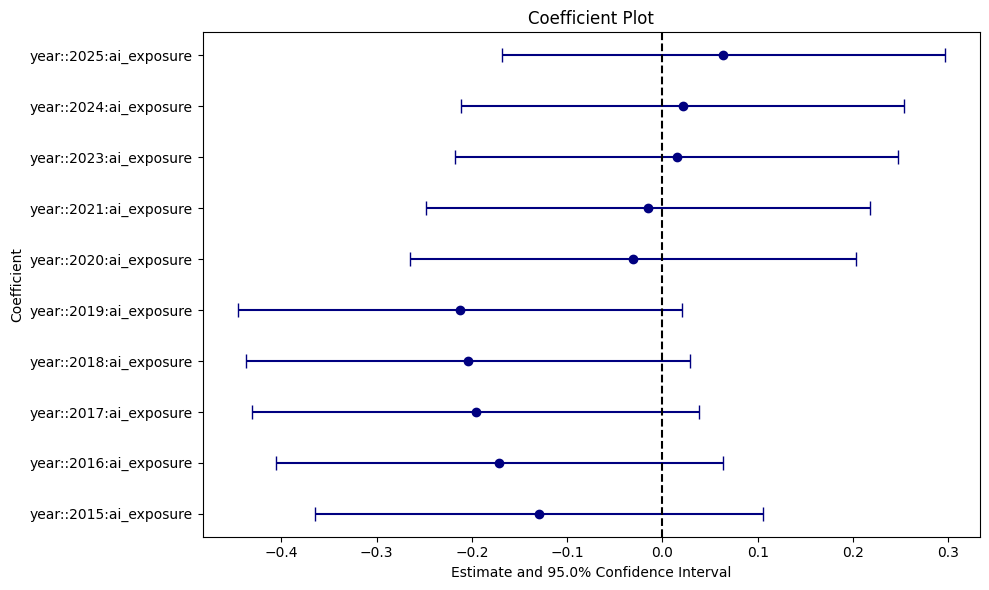

In [11]:
fit = pf.feols(
    "log_relation ~ i(year, ai_exposure, ref=2022) | kldb3 + year",
    data=df
)

fit.iplot()

In [12]:
fit = pf.feols(
    "log_relation ~ ai_exposure:post + log_bestand | kldb3 + year",
    data=df
)
fit.summary()

###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: kldb3 + year
sample: None = all
Inference:  iid
Observations:  1252

| Coefficient      |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| log_bestand      |     -0.100 |        0.050 |    -1.995 |      0.046 | -0.198 |  -0.002 |
| ai_exposure:post |      0.162 |        0.057 |     2.833 |      0.005 |  0.050 |   0.273 |
---
RMSE: 0.711 R2: 0.841 R2 Within: 0.01 


C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\formula\model_matrix.py:149: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


In [13]:
# reset index if needed
df_reset = df.reset_index()

# take pre-period (before 2023)
pre = df_reset[df_reset["year"] < 2023]

# compute average relation per occupation before ChatGPT
baseline = pre.groupby("kldb3")["relation"].mean().reset_index()

# define high slack occupations (>100)
baseline["high_slack"] = (baseline["relation"] > 100).astype(int)

# merge back
df_reset = df_reset.merge(baseline[["kldb3", "high_slack"]], on="kldb3", how="left")

In [14]:
df_reset["post"] = (df_reset["year"] >= 2023).astype(int)

# triple interaction
df_reset["ai_post_slack"] = (
    df_reset["ai_exposure"] *
    df_reset["post"] *
    df_reset["high_slack"]
)

In [15]:
import pyfixest as pf

fit = pf.feols(
    "log_relation ~ ai_exposure:post + ai_post_slack | kldb3 + year",
    data=df_reset
)

fit.summary()

###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: kldb3 + year
sample: None = all
Inference:  iid
Observations:  1252

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| ai_post_slack |      0.153 |        0.057 |     2.679 |      0.007 |  0.041 |   0.264 |
---
RMSE: 0.713 R2: 0.84 R2 Within: 0.006 


C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\models\feols_.py:2466: UserWarning: 
            1 variables dropped due to multicollinearity.
            The following variables are dropped: ['ai_exposure:post'].
            
  warnings.warn(


In [16]:
# High slack only
df_high = df_reset[df_reset["high_slack"] == 1]

fit_high = pf.feols(
    "log_relation ~ ai_exposure:post | kldb3 + year",
    data=df_high
)

# Low slack only
df_low = df_reset[df_reset["high_slack"] == 0]



In [17]:
print(df_reset["high_slack"].value_counts(dropna=False))

high_slack
1.0    1252
NaN       1
Name: count, dtype: int64


In [18]:
import pandas as pd
import numpy as np
import pyfixest as pf

# if df has index kldb3/year, reset it
df_reset = df.reset_index()

df_reset.columns = df_reset.columns.str.strip().str.lower()

# make numeric
df_reset["year"] = pd.to_numeric(df_reset["year"], errors="coerce")
df_reset["kldb3"] = pd.to_numeric(df_reset["kldb3"], errors="coerce")
df_reset["relation"] = pd.to_numeric(df_reset["relation"], errors="coerce")
df_reset["log_relation"] = pd.to_numeric(df_reset["log_relation"], errors="coerce")
df_reset["ai_exposure"] = pd.to_numeric(df_reset["ai_exposure"], errors="coerce")

# create post
df_reset["post"] = (df_reset["year"] >= 2023).astype(int)

# use pre-ChatGPT years only
pre = df_reset[df_reset["year"] < 2023].copy()

# average pre-ChatGPT relation by occupation
baseline = (
    pre.groupby("kldb3")["relation"]
    .mean()
    .reset_index(name="pre_relation")
)

# define groups
baseline["high_slack"] = (baseline["pre_relation"] > 100).astype(int)

# merge back
df_reset = df_reset.merge(
    baseline[["kldb3", "pre_relation", "high_slack"]],
    on="kldb3",
    how="left"
)

# check groups
print(df_reset["high_slack"].value_counts(dropna=False))

high_slack
1.0    1252
NaN       1
Name: count, dtype: int64


In [19]:
df_high = df_reset[df_reset["high_slack"] == 1].copy()

print("High slack rows:", len(df_high))
print("High slack occupations:", df_high["kldb3"].nunique())

fit_high = pf.feols(
    "log_relation ~ ai_exposure:post | kldb3 + year",
    data=df_high
)

fit_high.summary()

High slack rows: 1252
High slack occupations: 116
###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: kldb3 + year
sample: None = all
Inference:  iid
Observations:  1252

| Coefficient      |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| ai_exposure:post |      0.153 |        0.057 |     2.679 |      0.007 |  0.041 |   0.264 |
---
RMSE: 0.713 R2: 0.84 R2 Within: 0.006 


In [20]:
df_reset = df.reset_index()

# clean
df_reset.columns = df_reset.columns.str.strip().str.lower()

# create post
df_reset["post"] = (df_reset["year"] >= 2023).astype(int)

# define high AI (median split)
median_ai = df_reset["ai_exposure"].median()
df_reset["high_ai"] = (df_reset["ai_exposure"] > median_ai).astype(int)

print(df_reset["high_ai"].value_counts())

high_ai
0    671
1    582
Name: count, dtype: int64


In [21]:
import pyfixest as pf

fit = pf.feols(
    "log_relation ~ high_ai:post | kldb3 + year",
    data=df_reset
)

fit.summary()

###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: kldb3 + year
sample: None = all
Inference:  iid
Observations:  1252

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| high_ai:post  |      0.137 |        0.096 |     1.429 |      0.153 | -0.051 |   0.325 |
---
RMSE: 0.714 R2: 0.839 R2 Within: 0.002 


C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\formula\model_matrix.py:149: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


In [23]:
# ============================================================
# 0. INSTALL / IMPORT PACKAGES
# ============================================================

# Run once if needed:
# pip install pyfixest pandas numpy matplotlib

import pandas as pd
import numpy as np
import pyfixest as pf
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD DATA
# ============================================================

base = r"F:\M.Sc in Economics\Thesis paper"

df = pd.read_csv(base+r"\final_dataset_ai_exposure_controls.csv")

# Make sure variables are correctly formatted
df["kldb3"] = pd.to_numeric(df["kldb3"], errors="coerce").astype("Int64")
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
df["relation"] = pd.to_numeric(df["relation"], errors="coerce")
df["vakanz_tage"] = pd.to_numeric(df["vakanz_tage"], errors="coerce")
df["ai_exposure"] = pd.to_numeric(df["ai_exposure"], errors="coerce")

# Drop missing values
df = df.dropna(subset=["kldb3", "year", "relation", "vakanz_tage", "ai_exposure"]).copy()

# Keep only positive values before log
df = df[(df["relation"] > 0) & (df["vakanz_tage"] > 0)].copy()



# Post ChatGPT period
df["post"] = (df["year"] >= 2023).astype(int)

# Continuous DiD treatment
df["ai_post"] = df["ai_exposure"] * df["post"]

print(df.head())
print(df[["year", "kldb3", "relation", "vakanz_tage", "ai_exposure", "post"]].describe())

   kldb3  year  soc_major  bestand_absolut  vakanz_tage  relation  \
0    111  2015         45            478.0         68.0     538.0   
1    111  2016         45            486.0         74.0     562.0   
2    111  2017         45            598.0         77.0     432.0   
3    111  2018         45            797.0         91.0     288.0   
4    111  2019         45            793.0        106.0     269.0   

   log_bestand  log_vakanz  log_relation  ai_exposure  post  ai_post  
0     6.169611    4.219508      6.287859    -1.056699     0     -0.0  
1     6.186209    4.304065      6.331502    -1.056699     0     -0.0  
2     6.393591    4.343805      6.068426    -1.056699     0     -0.0  
3     6.680855    4.510860      5.662960    -1.056699     0     -0.0  
4     6.675823    4.663439      5.594711    -1.056699     0     -0.0  
              year       kldb3       relation  vakanz_tage  ai_exposure  \
count       1253.0      1253.0    1253.000000  1253.000000  1253.000000   
mean   20

In [24]:
# ============================================================
# MODEL 1: BASELINE — LOG RELATION
# ============================================================

m1 = pf.feols(
    "log_relation ~ ai_exposure | year",
    data=df,
    vcov={"CRV1": "kldb3"}
)

print(m1.summary())

###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: year
sample: None = all
Inference:  CRV1
Observations:  1253

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| ai_exposure   |      0.275 |        0.086 |     3.221 |      0.002 |  0.106 |   0.445 |
---
RMSE: 1.064 R2: 0.644 R2 Within: 0.045 
None


In [25]:
coef = m1.coef()["ai_exposure"]
percent_effect = (np.exp(coef) - 1) * 100

print(f"Coefficient: {coef:.4f}")
print(f"Approximate percent effect: {percent_effect:.2f}%")

Coefficient: 0.2755
Approximate percent effect: 31.72%


In [26]:
# ============================================================
# MODEL 2: BASELINE — LOG VACANCIES
# ============================================================

m2 = pf.feols(
    "log_vakanz ~ ai_exposure | year",
    data=df,
    vcov={"CRV1": "kldb3"}
)

print(m2.summary())

###

Estimation:  OLS
Dep. var.: log_vakanz, Fixed effects: year
sample: None = all
Inference:  CRV1
Observations:  1253

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| ai_exposure   |     -0.152 |        0.030 |    -5.122 |      0.000 | -0.211 |  -0.093 |
---
RMSE: 0.308 R2: 0.605 R2 Within: 0.145 
None


In [27]:
coef = m2.coef()["ai_exposure"]
percent_effect = (np.exp(coef) - 1) * 100

print(f"Coefficient: {coef:.4f}")
print(f"Approximate percent effect: {percent_effect:.2f}%")

Coefficient: -0.1518
Approximate percent effect: -14.09%


In [28]:
# ============================================================
# MODEL 3: CONTINUOUS DID — LOG RELATION
# ============================================================

did_relation = pf.feols(
    "log_relation ~ ai_exposure:post | kldb3 + year",
    data=df,
    vcov={"CRV1": "kldb3"}
)

print(did_relation.summary())

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\formula\model_matrix.py:149: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1252

| Coefficient      |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| ai_exposure:post |      0.153 |        0.096 |     1.593 |      0.114 | -0.037 |   0.342 |
---
RMSE: 0.713 R2: 0.84 R2 Within: 0.006 
None


In [29]:
coef = did_relation.coef()["ai_exposure:post"]
percent_effect = (np.exp(coef) - 1) * 100

print(f"Continuous DiD coefficient: {coef:.4f}")
print(f"Approximate post-2023 percent effect: {percent_effect:.2f}%")

Continuous DiD coefficient: 0.1525
Approximate post-2023 percent effect: 16.47%


In [30]:
# ============================================================
# MODEL 4: CONTINUOUS DID — LOG VACANCIES
# ============================================================

did_vakanz = pf.feols(
    "log_vakanz ~ ai_exposure:post | kldb3 + year",
    data=df,
    vcov={"CRV1": "kldb3"}
)

print(did_vakanz.summary())

###

Estimation:  OLS
Dep. var.: log_vakanz, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1252

| Coefficient      |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| ai_exposure:post |     -0.014 |        0.016 |    -0.870 |      0.386 | -0.046 |   0.018 |
---
RMSE: 0.141 R2: 0.917 R2 Within: 0.001 
None


C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\formula\model_matrix.py:149: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


In [31]:
coef = did_vakanz.coef()["ai_exposure:post"]
percent_effect = (np.exp(coef) - 1) * 100

print(f"Continuous DiD coefficient: {coef:.4f}")
print(f"Approximate post-2023 percent effect: {percent_effect:.2f}%")

Continuous DiD coefficient: -0.0139
Approximate post-2023 percent effect: -1.38%


C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\formula\model_matrix.py:149: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


###

Estimation:  OLS
Dep. var.: log_relation, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1252

| Coefficient            |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| year::2015:ai_exposure |     -0.129 |        0.155 |    -0.837 |      0.404 | -0.436 |   0.177 |
| year::2016:ai_exposure |     -0.171 |        0.158 |    -1.081 |      0.282 | -0.484 |   0.142 |
| year::2017:ai_exposure |     -0.196 |        0.150 |    -1.306 |      0.194 | -0.493 |   0.101 |
| year::2018:ai_exposure |     -0.204 |        0.155 |    -1.314 |      0.191 | -0.511 |   0.103 |
| year::2019:ai_exposure |     -0.213 |        0.154 |    -1.383 |      0.169 | -0.517 |   0.092 |
| year::2020:ai_exposure |     -0.031 |        0.017 |    -1.796 |      0.075 | -0.065 |   0.003 |
| year::2021:ai_exposure |     -0.015 |        0.009 |    -1.664 |      0.09

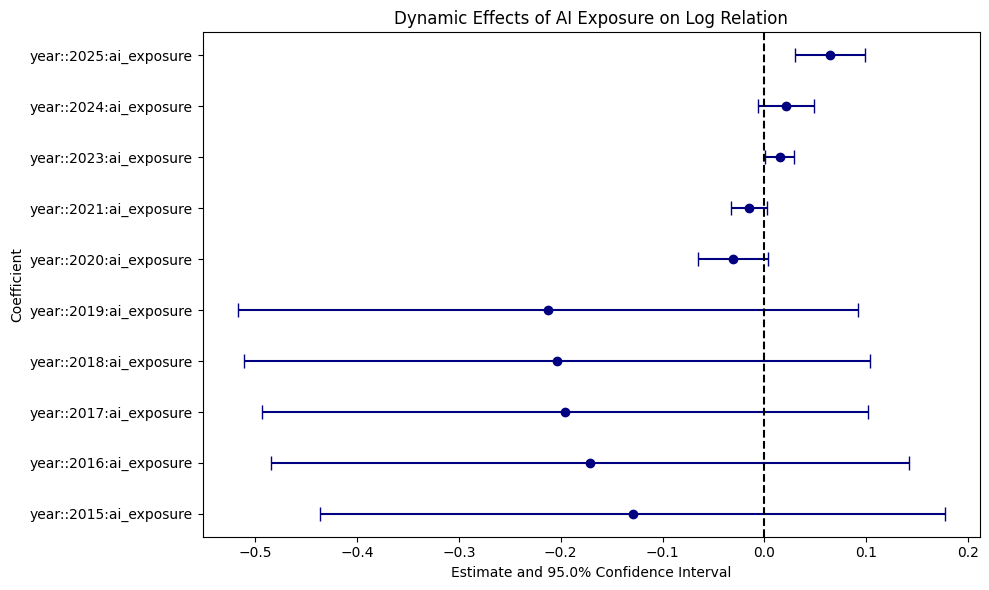

In [33]:
# ============================================================
# MODEL 5: EVENT STUDY — LOG RELATION
# Reference year = 2022
# ============================================================

event_relation = pf.feols(
    "log_relation ~ i(year, ai_exposure, ref=2022) | kldb3 + year",
    data=df,
    vcov={"CRV1": "kldb3"}
)

print(event_relation.summary())

# Plot
event_relation.iplot(
    title="Dynamic Effects of AI Exposure on Log Relation"
)

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\formula\model_matrix.py:149: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


###

Estimation:  OLS
Dep. var.: log_vakanz, Fixed effects: kldb3 + year
sample: None = all
Inference:  CRV1
Observations:  1252

| Coefficient            |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:-----------------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| year::2015:ai_exposure |      0.061 |        0.030 |     2.058 |      0.042 |  0.002 |   0.121 |
| year::2016:ai_exposure |      0.059 |        0.028 |     2.078 |      0.040 |  0.003 |   0.114 |
| year::2017:ai_exposure |      0.031 |        0.027 |     1.171 |      0.244 | -0.022 |   0.085 |
| year::2018:ai_exposure |     -0.007 |        0.023 |    -0.316 |      0.752 | -0.053 |   0.038 |
| year::2019:ai_exposure |     -0.013 |        0.019 |    -0.694 |      0.489 | -0.051 |   0.025 |
| year::2020:ai_exposure |      0.008 |        0.013 |     0.653 |      0.515 | -0.017 |   0.034 |
| year::2021:ai_exposure |     -0.008 |        0.012 |    -0.643 |      0.521 

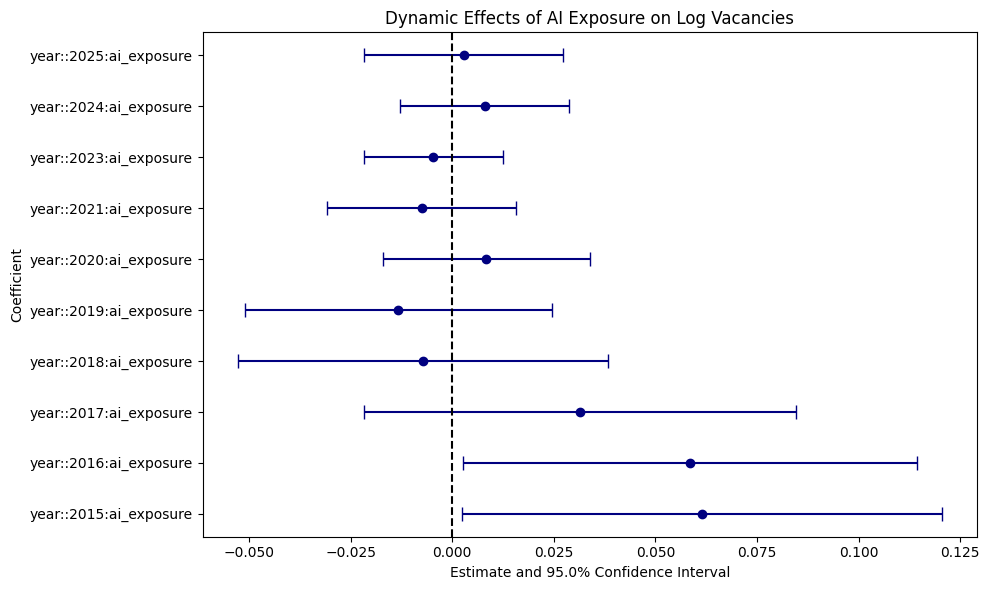

In [35]:
# ============================================================
# MODEL 6: EVENT STUDY — LOG VACANCIES
# Reference year = 2022
# ============================================================

event_vakanz = pf.feols(
    "log_vakanz ~ i(year, ai_exposure, ref=2022) | kldb3 + year",
    data=df,
    vcov={"CRV1": "kldb3"}
)

print(event_vakanz.summary())

# Plot
event_vakanz.iplot(

    title="Dynamic Effects of AI Exposure on Log Vacancies",
   
)

In [57]:
# ============================================================
# EXPORT TABLE
# ============================================================

pf.etable(
    [m1, m2, did_relation, did_vakanz, event_relation, event_vakanz],
    labels={
        "ai_exposure": "AI Exposure",
        "ai_exposure:post": "AI Exposure × Post-2023"
    }
)
table = pf.etable(
    [m1, m2, did_relation, did_vakanz, event_relation, event_vakanz],
    type="df"   # 👈 THIS is the key fix
)

print(table)
table.to_excel("regression_table.xlsx")

                                        log_relation        log_vakanz  \
                                                 (1)               (2)   
coef  ai_exposure                   0.275 \n (0.086)  -0.152 \n (0.03)   
      ai_exposure × post                                                 
      year ×  × 2015 × ai_exposure                                       
      year ×  × 2016 × ai_exposure                                       
      year ×  × 2017 × ai_exposure                                       
      year ×  × 2018 × ai_exposure                                       
      year ×  × 2019 × ai_exposure                                       
      year ×  × 2020 × ai_exposure                                       
      year ×  × 2021 × ai_exposure                                       
      year ×  × 2023 × ai_exposure                                       
      year ×  × 2024 × ai_exposure                                       
      year ×  × 2025 × ai_exposure    

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\formula\model_matrix.py:149: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(
C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\pyfixest\estimation\formula\model_matrix.py:149: UserWarning: 1 singleton fixed effect(s) dropped from the model.
  warnings.warn(


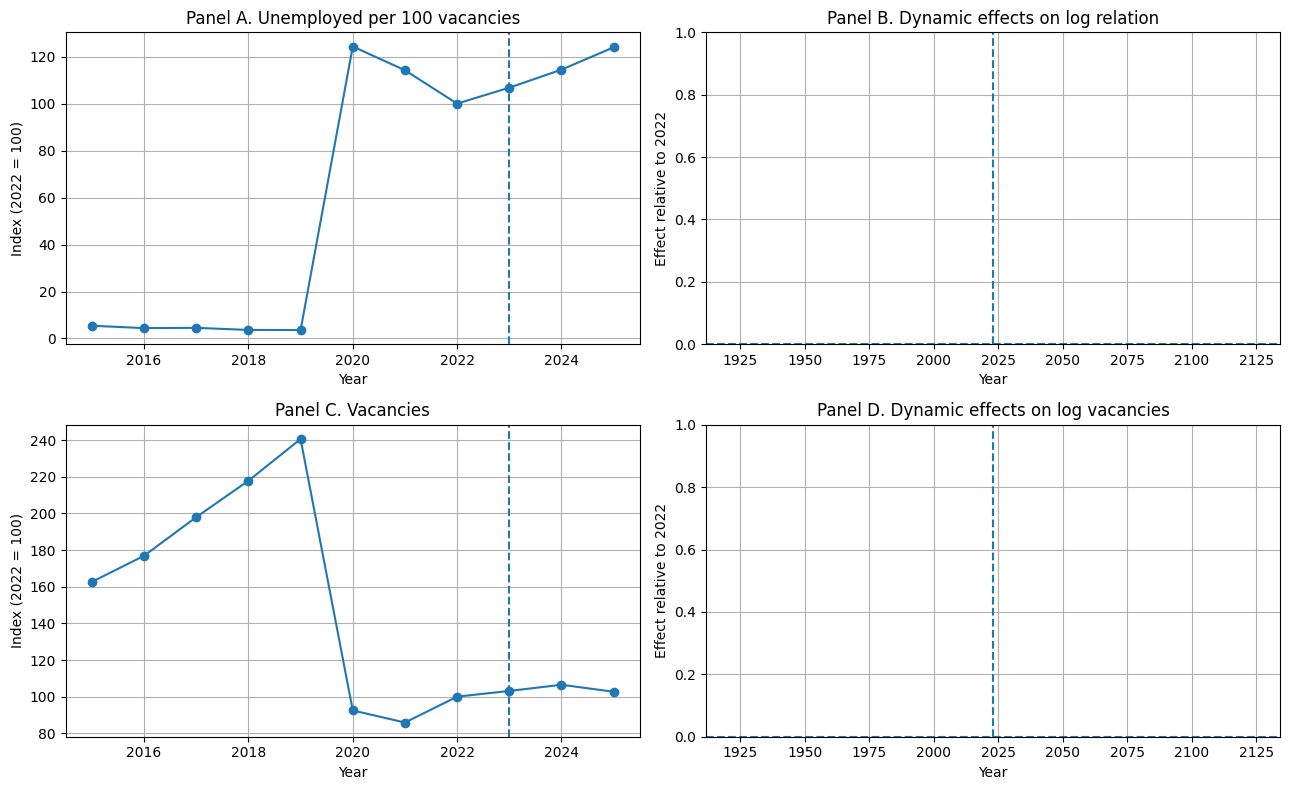

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyfixest as pf

# Make sure these exist
df["post"] = (df["year"] >= 2023).astype(int)

# --------------------------------------------------
# Event-study models
# --------------------------------------------------

event_relation = pf.feols(
    "log_relation ~ i(year, ai_exposure, ref=2022) | kldb3 + year",
    data=df,
    vcov={"CRV1": "kldb3"}
)

event_vakanz = pf.feols(
    "log_vakanz ~ i(year, ai_exposure, ref=2022) | kldb3 + year",
    data=df,
    vcov={"CRV1": "kldb3"}
)

# --------------------------------------------------
# Mean outcome by year
# --------------------------------------------------

yearly = (
    df.groupby("year", as_index=False)
      .agg(
          relation_mean=("relation", "mean"),
          vakanz_mean=("vakanz_tage", "mean")
      )
)

# Index to 2022 = 100
base_relation = yearly.loc[yearly["year"] == 2022, "relation_mean"].iloc[0]
base_vakanz = yearly.loc[yearly["year"] == 2022, "vakanz_mean"].iloc[0]

yearly["relation_index"] = yearly["relation_mean"] / base_relation * 100
yearly["vakanz_index"] = yearly["vakanz_mean"] / base_vakanz * 100

# --------------------------------------------------
# Create 2x2 figure
# --------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Panel A
axes[0, 0].plot(yearly["year"], yearly["relation_index"], marker="o")
axes[0, 0].axvline(2023, linestyle="--")
axes[0, 0].set_title("Panel A. Unemployed per 100 vacancies")
axes[0, 0].set_ylabel("Index (2022 = 100)")
axes[0, 0].set_xlabel("Year")
axes[0, 0].grid(True)

# Panel B
plt.sca(axes[0, 1])
event_relation.iplot()
axes[0, 1].axhline(0, linestyle="--")
axes[0, 1].axvline(2023, linestyle="--")
axes[0, 1].set_title("Panel B. Dynamic effects on log relation")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Effect relative to 2022")
axes[0, 1].grid(True)

# Panel C
axes[1, 0].plot(yearly["year"], yearly["vakanz_index"], marker="o")
axes[1, 0].axvline(2023, linestyle="--")
axes[1, 0].set_title("Panel C. Vacancies")
axes[1, 0].set_ylabel("Index (2022 = 100)")
axes[1, 0].set_xlabel("Year")
axes[1, 0].grid(True)

# Panel D
plt.sca(axes[1, 1])
event_vakanz.iplot()
axes[1, 1].axhline(0, linestyle="--")
axes[1, 1].axvline(2023, linestyle="--")
axes[1, 1].set_title("Panel D. Dynamic effects on log vacancies")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Effect relative to 2022")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [39]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def extract_event_study(model):
    coefs = model.coef()
    ci = model.confint()

    out = pd.DataFrame({
        "term": coefs.index.astype(str),
        "coef": coefs.values,
        "ci_low": ci.iloc[:, 0].values if hasattr(ci, "iloc") else ci[:, 0],
        "ci_high": ci.iloc[:, 1].values if hasattr(ci, "iloc") else ci[:, 1],
    })

    # keep only interaction terms with ai_exposure
    out = out[out["term"].str.contains("ai_exposure", case=False, regex=False)].copy()

    # extract year from any 4-digit number in the term
    out["year"] = out["term"].str.extract(r"(\d{4})").astype(int)

    # add omitted reference year 2022 manually
    ref = pd.DataFrame({
        "term": ["Reference year"],
        "coef": [0],
        "ci_low": [0],
        "ci_high": [0],
        "year": [2022]
    })

    out = pd.concat([out, ref], ignore_index=True)
    out = out.sort_values("year")

    return out

In [40]:
event_relation_df = extract_event_study(event_relation)
event_vakanz_df = extract_event_study(event_vakanz)

print(event_relation_df)
print(event_vakanz_df)

                      term      coef    ci_low   ci_high  year
0   year::2015:ai_exposure -0.129427 -0.435773  0.176920  2015
1   year::2016:ai_exposure -0.171026 -0.484321  0.142269  2016
2   year::2017:ai_exposure -0.195742 -0.492702  0.101219  2017
3   year::2018:ai_exposure -0.203652 -0.510576  0.103273  2018
4   year::2019:ai_exposure -0.212534 -0.516866  0.091797  2019
5   year::2020:ai_exposure -0.031039 -0.065264  0.003187  2020
6   year::2021:ai_exposure -0.014908 -0.032658  0.002843  2021
10          Reference year  0.000000  0.000000  0.000000  2022
7   year::2023:ai_exposure  0.014819  0.000291  0.029346  2023
8   year::2024:ai_exposure  0.021429 -0.006017  0.048875  2024
9   year::2025:ai_exposure  0.063929  0.029541  0.098317  2025
                      term      coef    ci_low   ci_high  year
0   year::2015:ai_exposure  0.061430  0.002310  0.120550  2015
1   year::2016:ai_exposure  0.058557  0.002738  0.114375  2016
2   year::2017:ai_exposure  0.031417 -0.021714  0.08454

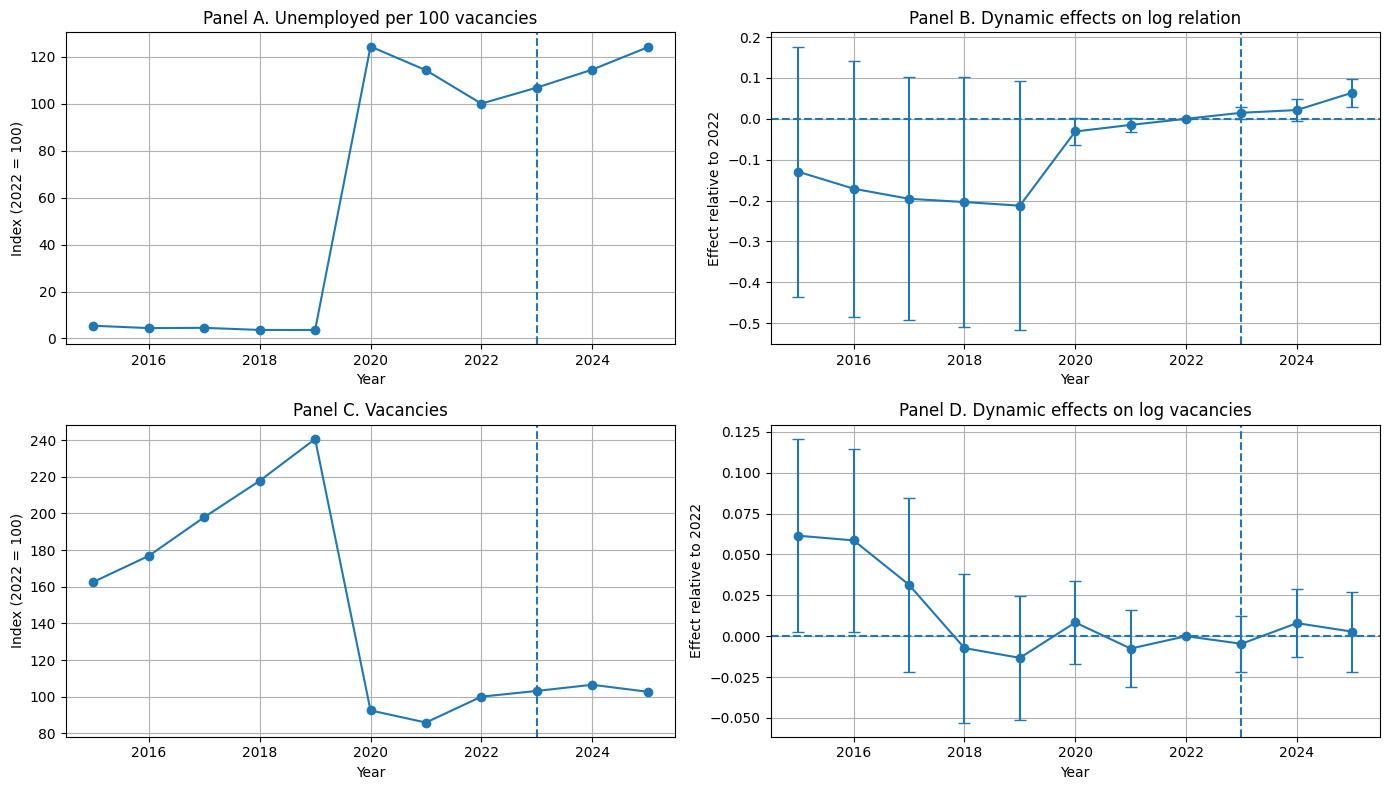

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Panel A
axes[0, 0].plot(yearly["year"], yearly["relation_index"], marker="o")
axes[0, 0].axvline(2023, linestyle="--")
axes[0, 0].set_title("Panel A. Unemployed per 100 vacancies")
axes[0, 0].set_ylabel("Index (2022 = 100)")
axes[0, 0].set_xlabel("Year")
axes[0, 0].grid(True)

# Panel B
axes[0, 1].errorbar(
    event_relation_df["year"],
    event_relation_df["coef"],
    yerr=[
        event_relation_df["coef"] - event_relation_df["ci_low"],
        event_relation_df["ci_high"] - event_relation_df["coef"]
    ],
    fmt="o-",
    capsize=4
)
axes[0, 1].axhline(0, linestyle="--")
axes[0, 1].axvline(2023, linestyle="--")
axes[0, 1].set_title("Panel B. Dynamic effects on log relation")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Effect relative to 2022")
axes[0, 1].grid(True)

# Panel C
axes[1, 0].plot(yearly["year"], yearly["vakanz_index"], marker="o")
axes[1, 0].axvline(2023, linestyle="--")
axes[1, 0].set_title("Panel C. Vacancies")
axes[1, 0].set_ylabel("Index (2022 = 100)")
axes[1, 0].set_xlabel("Year")
axes[1, 0].grid(True)

# Panel D
axes[1, 1].errorbar(
    event_vakanz_df["year"],
    event_vakanz_df["coef"],
    yerr=[
        event_vakanz_df["coef"] - event_vakanz_df["ci_low"],
        event_vakanz_df["ci_high"] - event_vakanz_df["coef"]
    ],
    fmt="o-",
    capsize=4
)
axes[1, 1].axhline(0, linestyle="--")
axes[1, 1].axvline(2023, linestyle="--")
axes[1, 1].set_title("Panel D. Dynamic effects on log vacancies")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Effect relative to 2022")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()